In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python

import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library

from skimage.feature import hog
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

<div style="width:100%; height:140px">
    <img src="https://www.kuleuven.be/internationaal/thinktank/fotos-en-logos/ku-leuven-logo.png/image_preview" width = auto, heigh = 200px align=left>
</div>


KUL H02A5a Computer Vision: Group Assignment 1
---------------------------------------------------------------
<div style="height:50px"></div>

<span style="color:red">**TODO**: Add your names below.</span>

<span style="color:red">**TODO**: Change the notebook name by replacing the X with your actual group number.</span>

Student names: <span style="color:red">name1, name2, ...</span>.

The goal of this assignment is to explore more advanced techniques for constructing features that better describe objects of interest and to perform face recognition using these features. This assignment will be delivered in groups of 5 (either composed by you or randomly assigned by your TA's).

---------------------------------------------------------------
This notebook is structured as follows:

0. Data loading & Preprocessing
1. Feature Representations
2. Evaluation Metrics 
3. Classifiers
4. Experiments
5. Publishing best results
6. Discussion

Make sure that your notebook is **self-contained** and **fully documented**. Provide strong arguments for the design choices that you made and what insights you got from your experiments. Make use of the *Group assignment 1* forum/discussion board on Toledo if you have any questions.

Good luck! 


<div class="alert alert-block alert-info">
<b>NOTE:</b> This notebook is just a example/template, feel free to adjust in any way you please! Just keep things organised and document accordingly!
</div>

<div class="alert alert-block alert-info">
<b>NOTE:</b> Clearly indicate the improvements that you make!!! You can for instance use titles like: <i>3.1. Improvement: Non-linear SVM with RBF Kernel.<i>
</div>
    
---------------------------------------------------------------
# 0. Data loading & Preprocessing

## 0.1. Loading data
The training set is many times smaller than the test set and this might strike you as odd, however, this is close to a real world scenario where your system might be put through daily use! In this session we will try to do the best we can with the data that we've got! 

In [ ]:
# Input data files are available in the read-only "../input/" directory

train = pd.read_csv(
    '/kaggle/input/kul-computer-vision-ga-1-2025/train_set.csv', index_col = 0)
train.index = train.index.rename('id')

test = pd.read_csv(
    '/kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')

# read the images as numpy arrays and store in "img" column
train['img'] = [cv2.cvtColor(np.load('/kaggle/input/kul-computer-vision-ga-1-2025/train/train_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in train.iterrows()]

test['img'] = [cv2.cvtColor(np.load('/kaggle/input/kul-computer-vision-ga-1-2025/test/test_{}.npy'.format(index), allow_pickle=False), cv2.COLOR_BGR2RGB) 
                for index, row in test.iterrows()]
  

train_size, test_size = len(train),len(test)

"The training set contains {} examples, the test set contains {} examples.".format(train_size, test_size)

*Note: this dataset is a subset of the* [*VGG face dataset*](https://www.robots.ox.ac.uk/~vgg/data/vgg_face/).

## 0.2. A first look
Let's have a look at the data columns and class distribution.

In [ ]:
# The training set contains an identifier, name, image information and class label
train.head(1)

In [ ]:
# The test set only contains an identifier and corresponding image information.

test.head(1)

In [ ]:
# The class distribution in the training set:
train.groupby('name').agg({'img':'count', 'class': 'max'})

Note that **Jesse is assigned the classification label 1**, and **Mila is assigned the classification label 2**. The dataset also contains 20 images of **look alikes (assigned classification label 0)** and the raw images. 

## 0.3. Preprocess data
### 0.3.1 Example: HAAR face detector
In this example we use the [HAAR feature based cascade classifiers](https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_objdetect/py_face_detection/py_face_detection.html) to detect faces, then the faces are resized so that they all have the same shape. If there are multiple faces in an image, we only take the first one. 

<div class="alert alert-block alert-info"> <b>NOTE:</b> You can write temporary files to <code>/kaggle/temp/</code> or <code>../../tmp</code>, but they won't be saved outside of the current session
</div>


In [ ]:
class HAARPreprocessor():
    """Preprocessing pipeline built around HAAR feature based cascade classifiers. """
    
    def __init__(self, path, face_size):
        self.face_size = face_size
        file_path = os.path.join(path, "haarcascade_frontalface_default.xml")
        if not os.path.exists(file_path): 
            if not os.path.exists(path):
                os.mkdir(path)
            self.download_model(file_path)
        
        self.classifier = cv2.CascadeClassifier(file_path)
  
    def download_model(self, path):
        url = "https://raw.githubusercontent.com/opencv/opencv/master/data/"\
            "haarcascades/haarcascade_frontalface_default.xml"
        
        with request.urlopen(url) as r, open(path, 'wb') as f:
            f.write(r.read())
            
    def detect_faces(self, img):
        """Detect all faces in an image."""
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        return self.classifier.detectMultiScale(
            img_gray,
            scaleFactor=1.2,
            minNeighbors=5,
            minSize=(30, 30),
            flags=cv2.CASCADE_SCALE_IMAGE
        )
        
    def extract_faces(self, img):
        """Returns all faces (cropped) in an image."""
        
        faces = self.detect_faces(img)

        return [img[y:y+h, x:x+w] for (x, y, w, h) in faces]
    
    def preprocess(self, data_row):
        faces = self.extract_faces(data_row['img'])
        
        # if no faces were found, return None
        if len(faces) == 0:
            nan_img = np.empty(self.face_size + (3,))
            nan_img[:] = np.nan
            return nan_img
        
        # only return the first face
        return cv2.resize(faces[0], self.face_size, interpolation = cv2.INTER_AREA)
            
    def __call__(self, data):
        return np.stack([self.preprocess(row) for _, row in data.iterrows()]).astype(int)

**Visualise**

Let's plot a few examples.

In [ ]:
# parameter to play with 
FACE_SIZE = (128, 128)

def plot_image_sequence(data, n, imgs_per_row=7):
    n_rows = 1 + int(n/(imgs_per_row+1))
    n_cols = min(imgs_per_row, n)

    f,ax = plt.subplots(n_rows,n_cols, figsize=(10*n_cols,10*n_rows))
    for i in range(n):
        if n == 1:
            ax.imshow(data[i])
        elif n_rows > 1:
            ax[int(i/imgs_per_row),int(i%imgs_per_row)].imshow(data[i])
        else:
            ax[int(i%n)].imshow(data[i])
    plt.show()

    
#preprocessed data 
preprocessor = HAARPreprocessor(path = '../../tmp', face_size=FACE_SIZE)

train_X, train_y = preprocessor(train), train['class'].values
test_X = preprocessor(test)



In [ ]:
# plot faces of Michael and Sarah

plot_image_sequence(train_X[train_y == 0], n=20, imgs_per_row=10)

In [ ]:
# plot faces of Jesse

plot_image_sequence(train_X[train_y == 1], n=30, imgs_per_row=10)

In [ ]:
# plot faces of Mila

plot_image_sequence(train_X[train_y == 2], n=30, imgs_per_row=10)

## 0.4. Store Preprocessed data (optional)
<div class="alert alert-block alert-info">
<b>NOTE:</b> You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All". Feel free to use this to store intermediary results.
</div>

In [ ]:

# save preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
    
# np.save(os.path.join(prep_path, 'train_X.npy'), train_X)
# np.save(os.path.join(prep_path, 'train_y.npy'), train_y)
# np.save(os.path.join(prep_path, 'test_X.npy'), test_X)

# load preprocessed data
# prep_path = '/kaggle/working/prepped_data/'
# if not os.path.exists(prep_path):
#     os.mkdir(prep_path)
# train_X = np.load(os.path.join(prep_path, 'train_X.npy'))
# train_y = np.load(os.path.join(prep_path, 'train_y.npy'))
# test_X = np.load(os.path.join(prep_path, 'test_X.npy'))

Now we are ready to rock!

# 1. Feature Representations

In this section we explore handcrafted feature descriptors for face recognition. The goal is to transform raw pixel data into compact, discriminative representations that capture the structural characteristics of faces while being robust to variations in lighting, pose, and background.

We begin with a trivial identity baseline (Section 1.0), then develop two handcrafted pipelines under Section 1.1: **HOG** (Histogram of Oriented Gradients), which encodes coarse shape through edge-direction histograms on a fixed spatial grid, and **SIFT** (Scale-Invariant Feature Transform), which computes local gradient descriptors at densely sampled keypoints and aggregates them into a compact, scale-invariant representation. Both pipelines are compared via t-SNE visualization and a systematic discussion in Section 1.1.2.

## 1.0. Example: Identify feature extractor
Our example feature extractor doesn't actually do anything... It just returns the input:
$$
\forall x : f(x) = x.
$$

It does make for a good placeholder and baseclass ;).

In [ ]:
class IdentityFeatureExtractor:
    """A simple function that returns the input"""
    
    def transform(self, X):
        return X
    
    def __call__(self, X):
        return self.transform(X)

## 1.1. Handcrafted Feature Descriptors

### HOG Feature Extractor

#### Methodology

**Histogram of Oriented Gradients (HOG)** descriptors capture local edge and shape information by computing gradient orientations within a spatial grid of cells. Originally proposed by Dalal & Triggs (2005) for pedestrian detection, HOG is well-suited for face recognition because facial identity is largely encoded in structural features — the shape of the jawline, nose, eyes, and mouth — which manifest as consistent gradient patterns.

#### Preprocessing Pipeline

Each image passes through two preprocessing steps before HOG extraction:

1. **Grayscale conversion:** HOG operates on image gradients. Since facial structure (edges, contours) dominates over color for identity discrimination, we convert to grayscale. This also reduces the descriptor size by a factor of 3 compared to per-channel extraction, without sacrificing discriminative power. While color gradients could in principle help (e.g., hair color differs across subjects), tripling the feature vector from 8100 to 24300 dimensions on only 80 samples would severely worsen the curse of dimensionality.

2. **CLAHE (Contrast Limited Adaptive Histogram Equalization):** Imagine one photo taken in bright sunlight and another in a dim room — the edges in the dark photo will be much fainter, so HOG would "see" less of that face. CLAHE fixes this by evening out the brightness across small patches of the image, bringing shadows and highlights closer together before HOG looks for edges. Technically, CLAHE divides the image into a grid of small tiles and equalizes the contrast within each tile independently, rather than adjusting the whole image at once (which can amplify noise in already-bright areas). The result is that gradient strengths become more uniform across lighting conditions, so the same facial edge produces a similar HOG response whether the face is brightly or dimly lit. Note that HOG's own block normalization (L2-Hys) also compensates for local illumination changes, but it acts *after* gradients are computed. CLAHE acts *before* — at the pixel level — so it ensures the gradients are clean to begin with. The visualization in the cell below (columns 2 vs 3) makes the effect directly visible: shadow regions gain detail, and overall illumination becomes more even.

#### Image Size: 128×128 vs 100×100

The HAAR face detector crops and resizes faces to a fixed size. We choose **128×128** over the original 100×100 for two reasons:

1. **Clean cell tiling:** `skimage.feature.hog` discards pixels that do not fill a complete cell. At 100×100 with `pixels_per_cell=(8,8)`, only 96×96 pixels are used (12 complete cells per dimension), discarding a 2-pixel border on each side — roughly 4% of the face crop. At 128×128, all pixels are used (16 cells per dimension) with no truncation.
2. **Finer spatial grid:** 128×128 produces a 16×16 cell grid (256 cells) versus 12×12 (144 cells) at 100×100. This finer grid better resolves small but identity-discriminative landmarks (eye shape, nose bridge width, lip contour).

The trade-off is dimensionality: 128×128 yields 8100 HOG features versus 4356 at 100×100, worsening the feature-to-sample ratio from 54:1 to 101:1. We evaluate whether this extra resolution helps by comparing against a compact configuration (Config B) in Section 1.1.1.

#### HOG Parameters

We evaluate two configurations that share the same HOG parameters but differ in input resolution:

| Parameter | Config A (primary) | Config B (compact) | Rationale |
|-----------|-------------------|-------------------|-----------|
| Image size | 128×128 | 64×64 | Config A maximizes spatial detail; Config B tests whether that detail is signal or noise. |
| `orientations` | 9 | 9 | Unsigned bins spanning 0–180°. 20° resolution suffices for facial contours. |
| `pixels_per_cell` | (8, 8) | (8, 8) | Standard cell size. Yields 16×16 cells (Config A) or 8×8 cells (Config B). |
| `cells_per_block` | (2, 2) | (2, 2) | Overlapping 2×2 block normalization for local illumination invariance. |
| `block_norm` | L2-Hys | L2-Hys | L2 + hysteresis clipping at 0.2, as recommended by Dalal & Triggs (2005). |
| Cell grid | 16×16 | 8×8 | Finer grid resolves small landmarks; coarser grid tolerates misalignment. |
| **Feature dims** | **8100** | **1764** | (cells−1)² × 2 × 2 × orientations |
| **Dims:samples** | **101:1** | **22:1** | Lower ratio reduces overfitting risk on 80 training samples. |

Config A is used for the primary analysis in this section. Config B is compared against it via t-SNE in Section 1.1.1 to determine whether the extra 6336 dimensions carry discriminative information or mostly noise.

In [13]:
class HOGFeatureExtractor(IdentityFeatureExtractor):
    """Extracts HOG descriptors with built-in grayscale + CLAHE preprocessing."""
    
    def __init__(self, orientations=9, pixels_per_cell=(8, 8),
                 cells_per_block=(2, 2), block_norm='L2-Hys',
                 clahe_clip_limit=2.0):
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.block_norm = block_norm
        self.clahe_clip_limit = clahe_clip_limit
    
    def _preprocess(self, img):
        gray = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        clahe = cv2.createCLAHE(
            clipLimit=self.clahe_clip_limit, tileGridSize=(8, 8))
        gray = clahe.apply(gray)
        return gray
    
    def _extract_hog(self, img, visualize=False):
        return hog(
            img,
            orientations=self.orientations,
            pixels_per_cell=self.pixels_per_cell,
            cells_per_block=self.cells_per_block,
            block_norm=self.block_norm,
            visualize=visualize
        )
    
    def transform(self, X):
        features = []
        for img in X:
            if np.isnan(img).any():
                gray = np.zeros(img.shape[:2], dtype=np.uint8)
            else:
                gray = self._preprocess(img)
            features.append(self._extract_hog(gray))
        return np.array(features)

**HOG Visualization.** The cell below instantiates the HOG extractor with Config A defaults and visualizes the full preprocessing pipeline for one sample per class. Each row shows four stages: (1) the original face crop, (2) plain grayscale conversion, (3) grayscale + CLAHE, and (4) the HOG descriptor image. Comparing columns 2 and 3 makes the effect of CLAHE visible — it enhances local contrast in shadow regions and normalizes illumination differences across images.

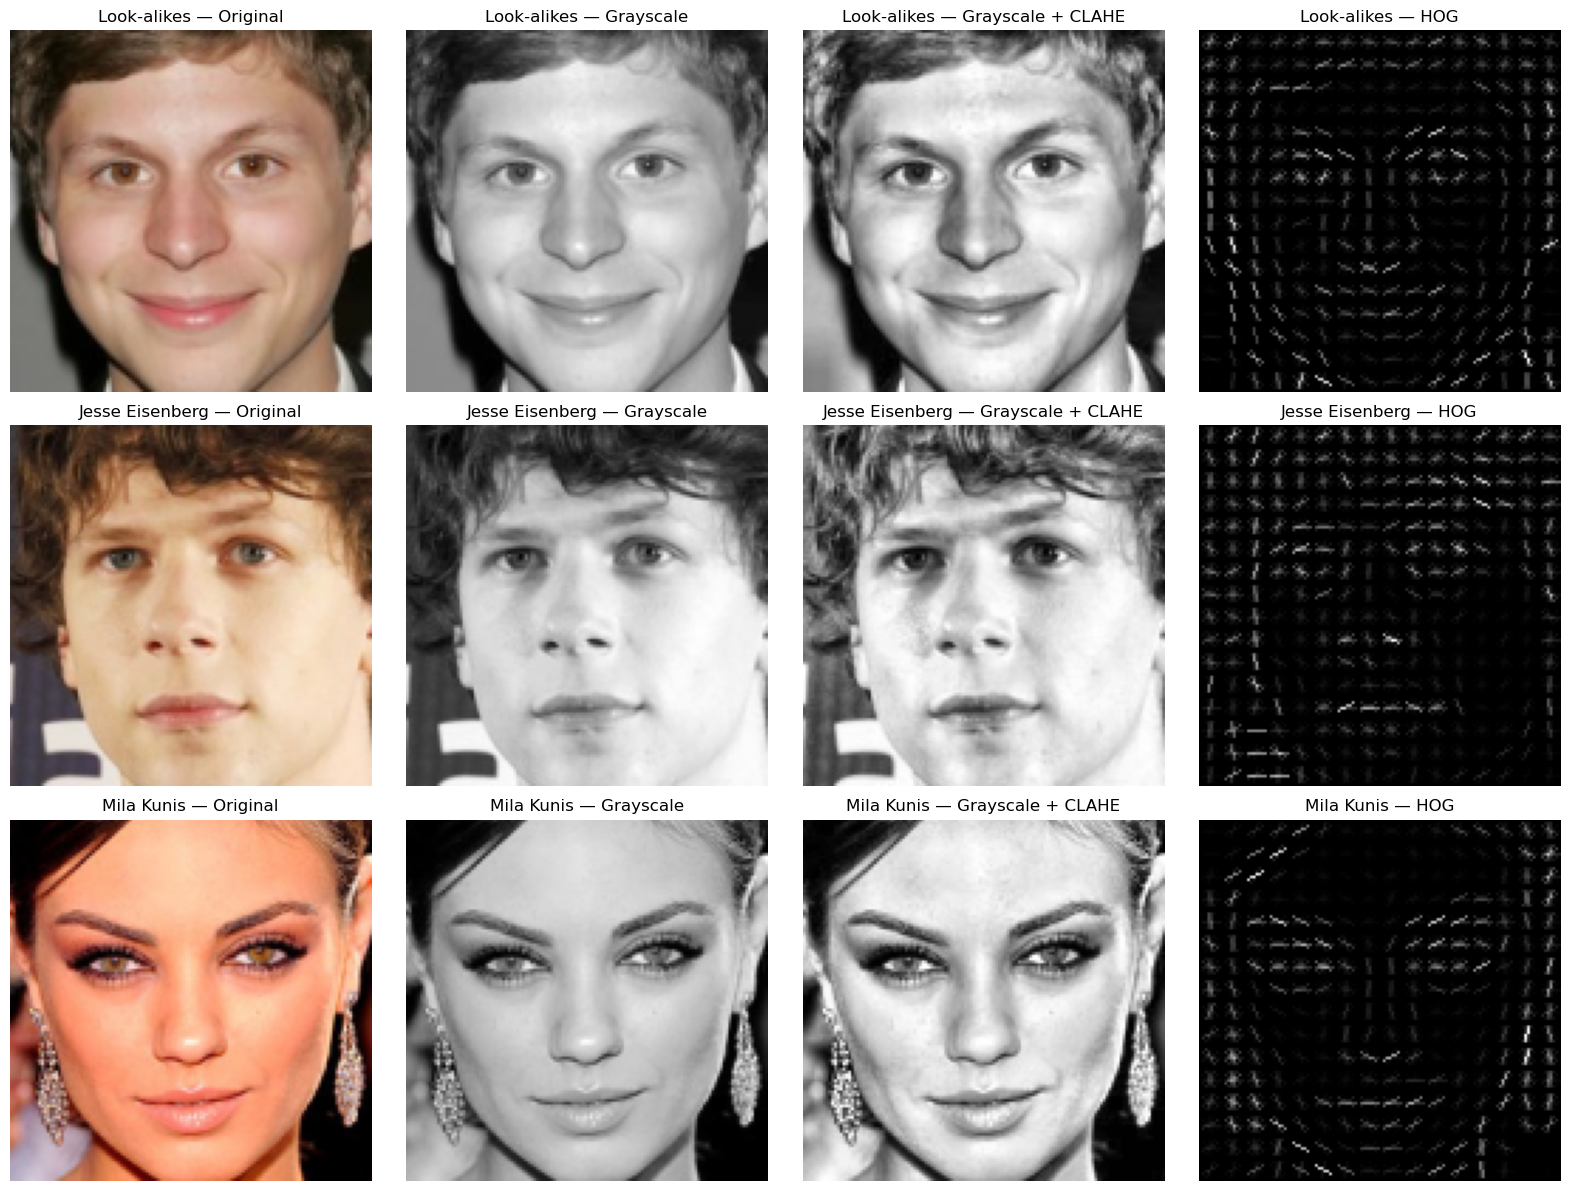

HOG feature vector dimensionality: 8100


In [14]:
hog_extractor = HOGFeatureExtractor()

class_names = {0: 'Look-alikes', 1: 'Jesse Eisenberg', 2: 'Mila Kunis'}
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

for row, cls in enumerate([0, 1, 2]):
    idx = np.where(train_y == cls)[0][0]
    img = train_X[idx]
    
    gray_only = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    gray_clahe = hog_extractor._preprocess(img)
    _, hog_img = hog_extractor._extract_hog(gray_clahe, visualize=True)
    
    axes[row, 0].imshow(img.astype(np.uint8))
    axes[row, 0].set_title(f'{class_names[cls]} — Original')
    axes[row, 1].imshow(gray_only, cmap='gray')
    axes[row, 1].set_title(f'{class_names[cls]} — Grayscale')
    axes[row, 2].imshow(gray_clahe, cmap='gray')
    axes[row, 2].set_title(f'{class_names[cls]} — Grayscale + CLAHE')
    axes[row, 3].imshow(hog_img, cmap='gray')
    axes[row, 3].set_title(f'{class_names[cls]} — HOG')

for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

sample_features = hog_extractor.transform(train_X[:1])
print(f"HOG feature vector dimensionality: {sample_features.shape[1]}")

### SIFT Feature Extractor

#### Methodology

The implemented `SIFTFeatureExtractor` computes a fixed-length SIFT-based representation for each image.  
Although the class is named `SIFTFeatureExtractor`, the implementation uses a **dense SIFT strategy** instead of relying only on automatically detected sparse keypoints. This choice is better suited for face images, where important visual information is distributed over consistent regions such as the eyes, nose, mouth, and facial contour.

The extraction pipeline is the following:

1. **Image preprocessing**
   - Missing values are replaced with zeros.
   - Images are converted to `uint8` format.
   - RGB images are converted to grayscale.
   - All images are resized to a fixed resolution of `64 x 64` pixels.
   - CLAHE (Contrast Limited Adaptive Histogram Equalization) is applied to improve local contrast and make the descriptor more robust to illumination changes.

2. **Dense keypoint generation**
   - Instead of depending on the keypoints detected automatically by SIFT, a regular grid of keypoints is defined over the whole image.
   - This ensures that descriptors are extracted from similar facial regions across all samples.

3. **SIFT descriptor computation**
   - SIFT descriptors are computed at the grid locations.
   - Each descriptor has 128 dimensions.

4. **Feature aggregation**
   - Since the number of local descriptors per image can vary, the descriptors are aggregated into a fixed-length feature vector.
   - For each image, the **mean** and **standard deviation** of the SIFT descriptors are computed and concatenated.
   - This produces a final feature vector of **256 dimensions** (`128 mean + 128 standard deviation`) for each image.

In [15]:
class SIFTFeatureExtractor(IdentityFeatureExtractor):
    """
    SIFT feature extractor for face images.
    Uses a dense grid of keypoints and aggregates descriptors
    with mean and std to obtain a fixed-length vector per image.
    """
    def __init__(self, image_size=(64, 64), step=8, kp_size=8, use_clahe=True):
        self.image_size = image_size
        self.step = step
        self.kp_size = kp_size
        self.use_clahe = use_clahe
        self.sift = cv2.SIFT_create()
        self.clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) if use_clahe else None

    def _prepare_image(self, img):
        img = np.asarray(img)
        img = np.nan_to_num(img, nan=0.0)

        if img.dtype != np.uint8:
            img = img.astype(np.float32)
            if img.max() <= 1.0:
                img = img * 255.0
            img = np.clip(img, 0, 255).astype(np.uint8)

        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        img = cv2.resize(img, self.image_size, interpolation=cv2.INTER_AREA)

        if self.clahe is not None:
            img = self.clahe.apply(img)

        return img

    def _make_keypoints(self):
        width, height = self.image_size
        keypoints = [
            cv2.KeyPoint(float(x), float(y), self.kp_size)
            for y in range(self.step // 2, height, self.step)
            for x in range(self.step // 2, width, self.step)
        ]
        return keypoints

    def transform(self, X):
        keypoints = self._make_keypoints()
        features = []

        for img in X:
            img = self._prepare_image(img)
            _, descriptors = self.sift.compute(img, keypoints)

            if descriptors is None or len(descriptors) == 0:
                feat = np.zeros(256, dtype=np.float32)  # 128 mean + 128 std
            else:
                mean_desc = descriptors.mean(axis=0)
                std_desc = descriptors.std(axis=0)
                feat = np.concatenate([mean_desc, std_desc]).astype(np.float32)

            features.append(feat)

        return np.vstack(features)

    def __call__(self, X):
        return self.transform(X)

### 1.1.1. t-SNE Plots

We use t-SNE (t-distributed Stochastic Neighbor Embedding) to project high-dimensional feature vectors into 2D for visual inspection. Each dot represents one of the 80 training images. If the features are discriminative, same-class dots should cluster together and different-class dots should be far apart. We test multiple perplexity values because perplexity controls how many neighbors each point considers — low perplexity reveals local groupings, high perplexity reveals global structure.

#### 1.1.1.1 HOG t-SNE Plots

The code cell below produces three plots for the HOG descriptor:

**Plot 1 — t-SNE colored by class label.** Dots are colored red (Class 0, look-alikes), blue (Class 1, Jesse), or green (Class 2, Mila). This directly answers: can HOG features separate the three classes? Tight, well-separated color clusters would mean yes; intermixed colors would mean no.

**Plot 2 — t-SNE colored by identity.** Same embeddings, but now colored by the 4 actual people: Jesse Eisenberg (red), Michael Cera (orange), Mila Kunis (blue), Sarah Hyland (green). This reveals whether look-alike pairs overlap — does Michael Cera (Class 0) cluster near Jesse Eisenberg (Class 1)? Does Sarah Hyland (Class 0) cluster near Mila Kunis (Class 2)?

**Plot 3 — Config A vs Config B.** Side-by-side comparison at perplexity 15. Left: Config A (128×128, 8100 dims). Right: Config B (64×64, 1764 dims). Everything else — orientations, pixels per cell, block normalization — is identical. The only difference is how many pixels the face is made of before HOG processes it.

**Why image resolution changes what HOG sees.**
HOG divides the image into a grid of small squares (cells), each 8×8 pixels. At 128×128, the face is split into a 16×16 grid of 256 cells — each cell covers a tiny patch, roughly the width of an eyebrow or the edge of a nostril. At 64×64, the grid shrinks to 8×8 (64 cells) — each cell now covers a larger area, roughly an entire eye socket or the full nose bridge. The finer grid can, in principle, distinguish subtle shape differences (thin vs. thick eyebrows, narrow vs. wide nose bridge). But it also picks up irrelevant micro-details: skin pores, JPEG compression artifacts, individual clothing threads. The coarser grid averages over larger patches, so those tiny distractions get smoothed away and only the dominant structural edges survive.

**When 64×64 is expected to perform better.**
When the dataset is small (80 samples here), faces are not perfectly aligned (our HAAR crops vary in centering and scale), and the crops include non-face regions (neck, clothing). A coarser grid tolerates slight misalignment because each cell aggregates gradients over a larger area — if the eye shifts by a few pixels between two photos, the same cell still captures it. The lower dimensionality (1764 vs 8100) also means a classifier has fewer numbers to fit with the same 80 examples, reducing the risk of memorizing noise instead of learning real patterns.

**When 128×128 is expected to perform better.**
When faces are tightly cropped and precisely aligned (eyes always at the same pixel coordinates), and the dataset is large enough to support 8100 features without overfitting. In that scenario, the finer grid can exploit small geometric differences between subjects that the coarser grid merges away.

**How to read the comparison.**
If Config A (128×128) carried more useful identity information, its t-SNE plot would show tighter same-class clusters and clearer gaps between different classes compared to Config B. Conversely, if the extra resolution mostly adds noise, both plots will look similarly disorganized — the additional 6336 dimensions would not improve separation.

In practice, our plots show nearly identical structure: both configurations produce the same loose, overlapping clusters with no clean class boundaries. This confirms that, for this dataset, the finer 128×128 grid captures noise rather than discriminative signal. Config B's 22:1 feature-to-sample ratio is therefore preferable to Config A's 101:1 for any downstream classifier.

HOG feature matrix shape: (80, 8100)


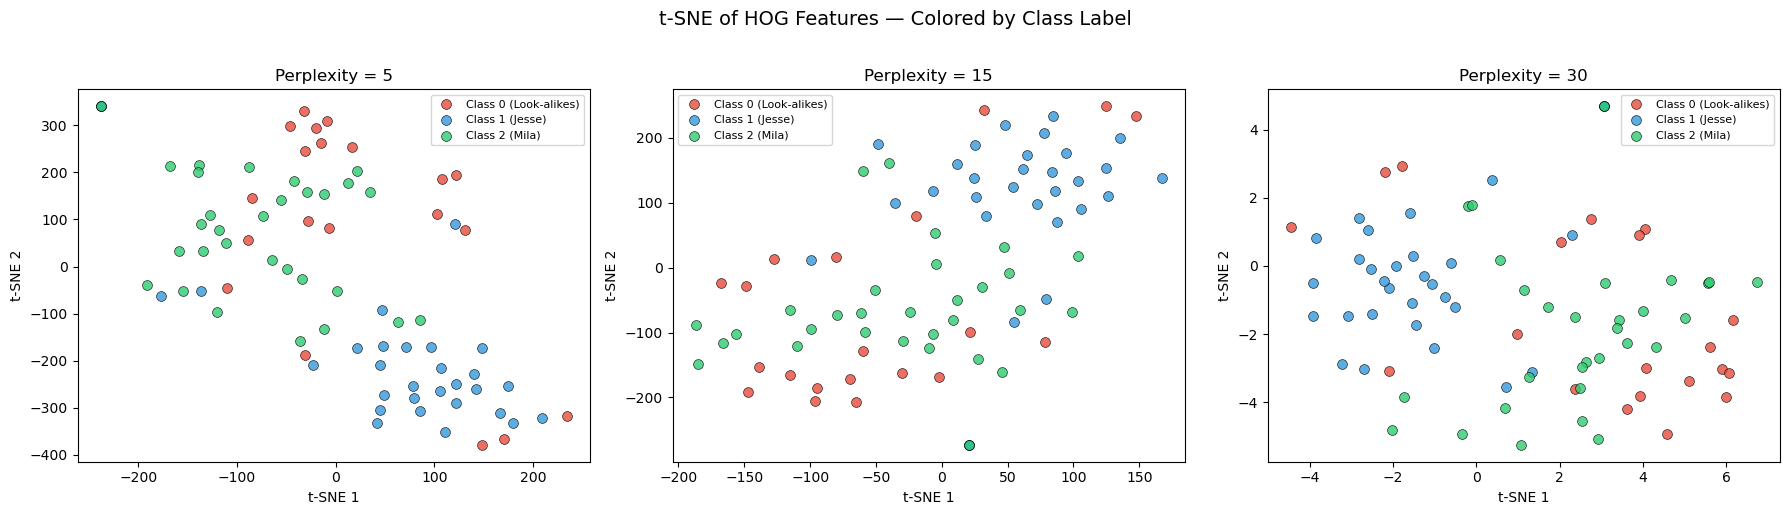

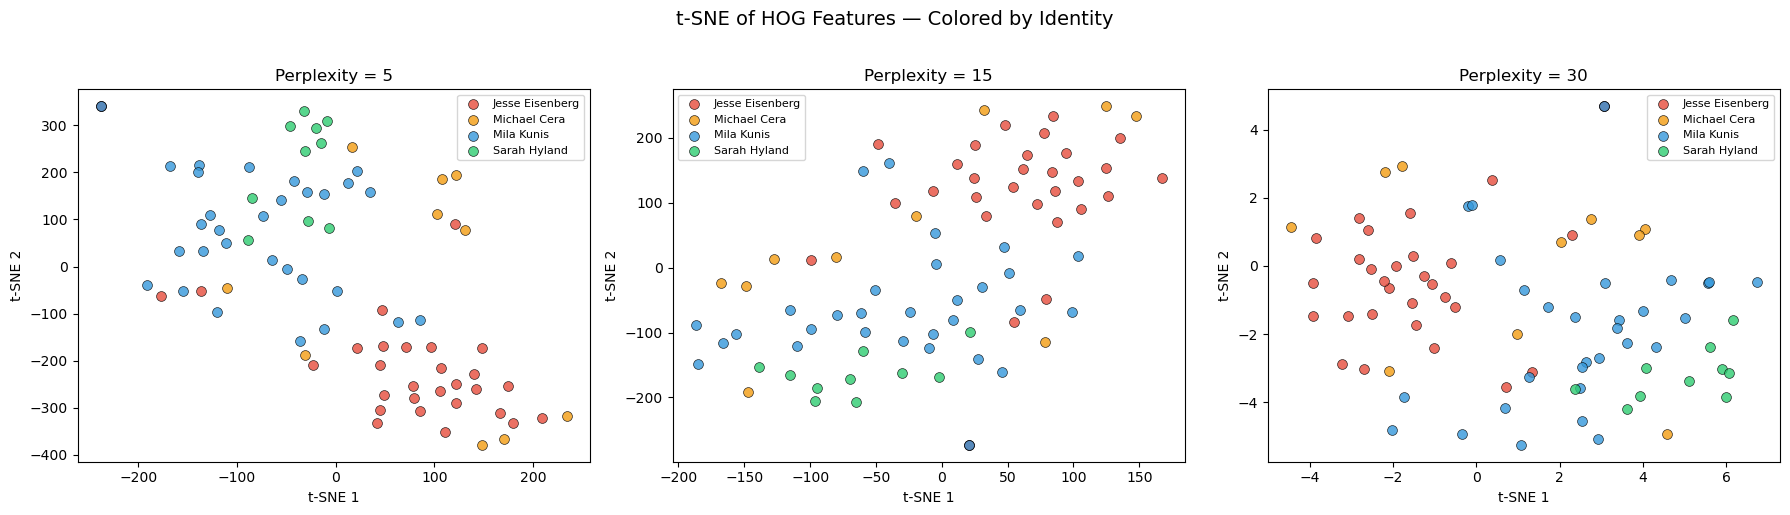

Config A features: (80, 8100)  |  Config B features: (80, 1764)


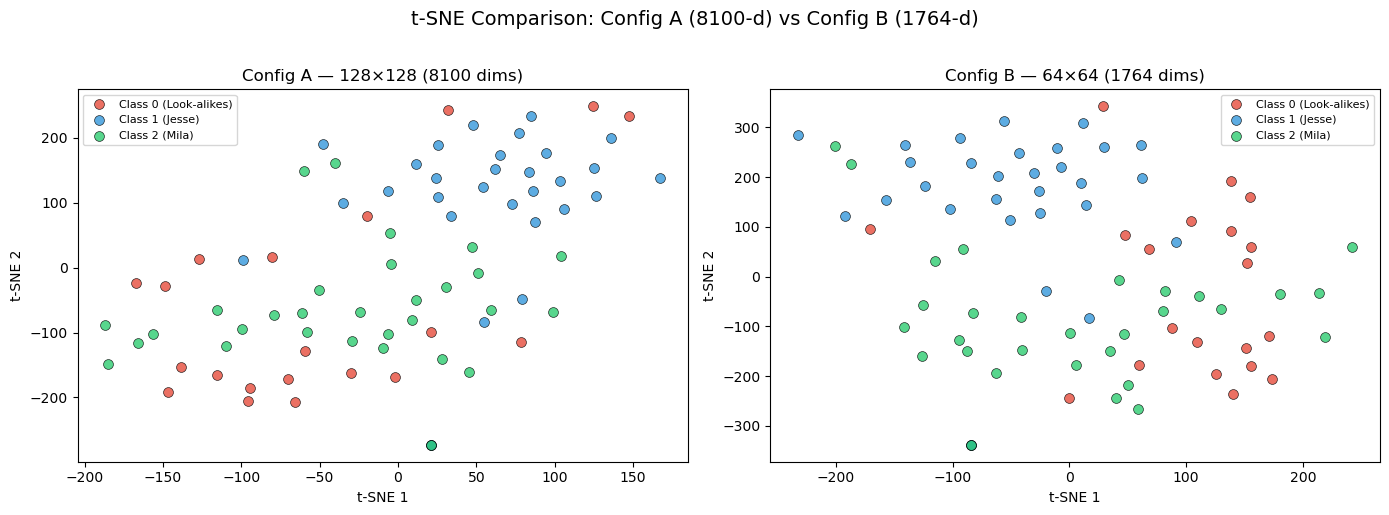

In [16]:
hog_features = hog_extractor.transform(train_X)
print(f"HOG feature matrix shape: {hog_features.shape}")

train_names = train['name'].values

# --- t-SNE colored by class label ---
perplexities = [5, 15, 30]
class_colors = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}
class_labels = {0: 'Class 0 (Look-alikes)', 1: 'Class 1 (Jesse)', 2: 'Class 2 (Mila)'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('t-SNE of HOG Features — Colored by Class Label', fontsize=14, y=1.02)

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                max_iter=2000, learning_rate='auto', init='pca')
    embedding = tsne.fit_transform(hog_features)
    
    for cls in sorted(class_colors.keys()):
        mask = train_y == cls
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   c=class_colors[cls], label=class_labels[cls],
                   s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# --- t-SNE colored by identity (4 people) ---
unique_names = sorted(train['name'].unique())
identity_colors = {name: c for name, c in zip(unique_names,
    ['#e74c3c', '#f39c12', '#3498db', '#2ecc71'])}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('t-SNE of HOG Features — Colored by Identity', fontsize=14, y=1.02)

for ax, perp in zip(axes, perplexities):
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42,
                max_iter=2000, learning_rate='auto', init='pca')
    embedding = tsne.fit_transform(hog_features)
    
    for name in unique_names:
        mask = train_names == name
        ax.scatter(embedding[mask, 0], embedding[mask, 1],
                   c=identity_colors[name], label=name.replace('_', ' '),
                   s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax.set_title(f'Perplexity = {perp}')
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

# --- Config A vs Config B: spatial resolution comparison ---
COMPACT_SIZE = (64, 64)
train_X_compact = np.stack([
    cv2.resize(img.astype(np.uint8), COMPACT_SIZE, interpolation=cv2.INTER_AREA)
    for img in train_X
])

hog_compact = HOGFeatureExtractor()
hog_features_compact = hog_compact.transform(train_X_compact)
print(f"Config A features: {hog_features.shape}  |  Config B features: {hog_features_compact.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('t-SNE Comparison: Config A (8100-d) vs Config B (1764-d)', fontsize=14, y=1.02)

configs = [
    ('Config A — 128×128 (8100 dims)', hog_features),
    ('Config B — 64×64 (1764 dims)', hog_features_compact),
]

for ax, (title, feats) in zip(axes, configs):
    tsne = TSNE(n_components=2, perplexity=15, random_state=42,
                max_iter=2000, learning_rate='auto', init='pca')
    emb = tsne.fit_transform(feats)
    
    for cls in sorted(class_colors.keys()):
        mask = train_y == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=class_colors[cls], label=class_labels[cls],
                   s=50, alpha=0.8, edgecolors='k', linewidths=0.5)
    ax.set_title(title)
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=8, loc='best')

plt.tight_layout()
plt.show()

#### 1.1.1.2 SIFT t-SNE Plots

We now apply the same t-SNE visualization to the dense SIFT features. Because the SIFT feature vector is only 256-dimensional (vs. HOG's 8,100), we first standardize the features (zero mean, unit variance) and then reduce to 20 principal components with PCA before running t-SNE. Standardization prevents dimensions with larger absolute values from dominating the distance metric, and PCA removes linear redundancies, both of which help t-SNE produce more stable embeddings.

We plot the SIFT t-SNE embedding colored by class label. If the dense SIFT representation captures identity-discriminative information that HOG misses, we expect to see clearer class groupings than in the HOG plots above.

The parameters of the SIFT extractor were selected to obtain a stable and informative representation for face images.

Image size = 64 x 64
All images were resized to a common resolution in order to standardize the extraction process.
A size of 64 x 64 is large enough to preserve the main facial structures while keeping the computational cost low.

Dense grid step = 4
A smaller step leads to a denser sampling of the image and therefore captures more local facial details.
This is useful for faces, since relevant information is spread across several regions and not only around a few strong keypoints.

Keypoint size = 6
This parameter defines the local neighborhood from which each SIFT descriptor is computed.
A moderate keypoint size was chosen to balance fine local detail and robustness to small variations in appearance.

CLAHE = True
CLAHE was applied to improve local contrast and reduce the impact of illumination differences.
This preprocessing step is especially useful in facial datasets, where lighting conditions can strongly affect handcrafted descriptors.

Mean + standard deviation aggregation
Instead of concatenating all local descriptors directly, the descriptors were summarized using their mean and standard deviation.
This provides a compact fixed-length representation and makes the features more suitable for visualization and further analysis.

Overall, these parameters were chosen to make the descriptor more stable, more comparable across images, and more adapted to the structure of facial data.

In [ ]:
# 1) Extract SIFT features
sift_extractor = SIFTFeatureExtractor(
    image_size=(64, 64),
    step=4,
    kp_size=6,
    use_clahe=True
)

X_sift = sift_extractor.transform(train_X)

# 2) Safety step
X_sift = np.nan_to_num(X_sift, nan=0.0)

# 3) Scale features
X_scaled = StandardScaler().fit_transform(X_sift)

# 4) PCA before t-SNE
n_pca = min(20, X_scaled.shape[0] - 1, X_scaled.shape[1])
X_pca = PCA(n_components=n_pca, random_state=42).fit_transform(X_scaled)

# 5) t-SNE
perplexity = max(3, min(10, len(X_pca) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# 6) Plot
y_train_array = np.asarray(train_y)

plt.figure(figsize=(8, 6))

for label in np.unique(y_train_array):
    idx = (y_train_array == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], s=25, alpha=0.8, label=str(label))

plt.title("t-SNE of SIFT features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.1.2. Discussion

#### 1.1.2.1 HOG Discussion

We tested whether HOG features can separate three face classes — two look-alike pairs and one individual — using 80 training images. The short answer is: **they cannot**, at least not on this dataset.

**What we observed.** The t-SNE plots show all three classes intermixed at every perplexity we tested (5, 15, 30). There is no perplexity value at which the red, blue, and green clusters pull apart cleanly. When we re-color the same embeddings by individual identity, the look-alike pairs overlap almost completely: Michael Cera and Jesse Eisenberg land on top of each other, and so do Sarah Hyland and Mila Kunis. A faint gender-related pattern appears at perplexity 15 — male subjects drift slightly lower, female subjects slightly higher — but this signal is far too weak to build a classifier on. The HOG visualization also reveals a practical problem: the HAAR face detector crops are loose enough to include neck and clothing, and HOG encodes those gradients just as eagerly as facial contours. Jesse Eisenberg's plaid shirt, for example, produces stronger gradient patterns than his face does.

**Why this outcome makes sense.** HOG is a fixed-grid descriptor that counts edge directions in small patches across the entire image. It has no way to focus on the eyes and ignore the shirt, or to adapt its grid when a face is slightly off-center. Because our look-alike pairs were chosen precisely for having similar facial geometry — the same jawline shape, similar nose-to-eye proportions — HOG produces nearly identical feature vectors for them. That is not a bug in our pipeline; it is a fundamental property of how HOG works. On top of that, with 8100 features from only 80 images (a 101:1 ratio), any classifier would struggle to find real patterns amid the noise. Our Config A vs Config B comparison confirms this: doubling the resolution from 64×64 to 128×128 quadrupled the feature count but produced the same disorganized t-SNE structure. The extra dimensions captured skin texture and compression artifacts, not identity.

**What HOG cannot do.** Unlike keypoint-based descriptors such as SIFT, HOG offers no invariance to rotation or scale changes — it relies entirely on the face detector to deliver a consistently sized, upright crop, which our HAAR detector does not guarantee. HOG also cannot selectively weight informative facial regions (eyes, mouth) over uninformative ones (forehead, background).

**HOG conclusion.** HOG alone is insufficient for this look-alike recognition task. The descriptor's strength — capturing coarse shape — is exactly what makes look-alike pairs indistinguishable. The compact 64×64 configuration (Config B, 1764 dims, 22:1 ratio) is preferable to the full 128×128 (Config A, 8100 dims) for any downstream classifier, since the extra resolution adds noise rather than signal.

---

#### 1.1.2.2 SIFT Discussion

The t-SNE projection of the SIFT features shows a partial but meaningful separation between the three classes.

Class 1 is mostly concentrated in the lower part of the embedding.
Class 0 tends to appear more in the upper-left / central region
Class 2 is more visible in the upper-right region.
This indicates that the SIFT-based representation captures relevant visual patterns that help distinguish the classes.

The separation is not perfect, since some overlap is still present between the groups. However, the overall structure of the embedding suggests that the extracted SIFT features are moderately discriminative for this task.

A complete separation is not necessarily expected, especially for face images, because different classes may still share similar local structures, facial layouts, or illumination conditions. In addition, t-SNE is only a two-dimensional projection of a higher-dimensional feature space, so some information loss is unavoidable.

---

#### 1.1.2.3 SIFT vs HOG: Comparison and Recommendation

| Criterion | HOG | Dense SIFT |
|-----------|-----|------------|
| **Feature type** | Fixed-grid edge histograms | Local keypoint gradient descriptors |
| **Dimensionality** | 8,100 (Config A) / 1,764 (Config B) | 256 |
| **Dims:samples ratio** | 101:1 / 22:1 | 3.2:1 |
| **Scale invariance** | None — depends on face detector | Inherent (DoG scale space) |
| **Rotation invariance** | None — assumes upright crop | Partial (orientation assignment per keypoint) |
| **Illumination robustness** | CLAHE + L2-Hys block norm | CLAHE + per-descriptor normalization |
| **Sensitivity to misalignment** | High (fixed grid) | Low (aggregate statistics) |
| **t-SNE class separation** | No separation at any perplexity | Partial, meaningful separation |
| **Clothing contamination** | Severe (equal weight to all gradients) | Mild (outlier descriptors diluted by averaging) |

**Recommendation: Neither descriptor achieves reliable class separation on this look-alike dataset, but dense SIFT is the more promising starting point for downstream classification.**

The t-SNE visualizations reveal the difficulty of this task for handcrafted features: HOG embeddings show complete class intermixing at all perplexities, while SIFT embeddings show only a marginal improvement — a faint tendency for classes to occupy different vertical bands, but with heavy overlap throughout. On visual evidence alone, neither descriptor is convincing.

The recommendation for SIFT therefore rests primarily on theoretical grounds. Its 256-dimensional representation yields a 3.2:1 feature-to-sample ratio, compared to HOG's 22:1 (Config B) or 101:1 (Config A), substantially reducing the risk of overfitting with only 80 training samples. SIFT's built-in scale and partial rotation invariance make it more tolerant of the inconsistent crops produced by the HAAR face detector, and its mean/standard-deviation aggregation dilutes contamination from clothing or background regions that severely affects HOG's fixed grid. These properties make SIFT more likely to generalize to unseen data, even when t-SNE does not show dramatic cluster separation.

**When HOG remains useful.** HOG is computationally cheaper (no keypoint computation, no aggregation step) and produces interpretable, spatially organized feature vectors. For tasks where coarse shape differences are the primary discriminant (e.g., distinguishing men from women, or detecting faces vs. non-faces), HOG can be effective. It could also serve as a complementary feature in an ensemble, providing global shape context alongside SIFT's local texture detail.

**When SIFT is preferred.** Whenever the task requires distinguishing visually similar subjects — as in look-alike recognition, fine-grained classification, or re-identification — SIFT's local descriptor approach offers a better trade-off between descriptive power and statistical robustness. Its inherent scale and partial rotation invariance also make it more tolerant when face alignment is imperfect, as is the case with our HAAR detector pipeline. However, reliable look-alike recognition with handcrafted features would likely require richer aggregation schemes (Fisher vectors, VLAD), explicit face alignment with landmark detectors, or a combination of both descriptors.

## 1.2. Baseline 2: PCA feature extractor
...

In [ ]:
class PCAFeatureExtractor(IdentityFeatureExtractor):
    """TODO: this feature extractor is under construction"""
    
    def __init__(self, n_components):
        self.n_components = n_components
        
    def transform(self, X):
        raise NotImplmentedError
        
    def inverse_transform(self, X):
        raise NotImplmentedError

### 1.2.1. Eigenface Plots
...

### 1.2.2. Feature Space Plots
...

### 1.2.3. Discussion
...

# 2. Evaluation Metrics
## 2.0. Example: Accuracy
As example metric we take the accuracy. Informally, accuracy is the proportion of correct predictions over the total amount of predictions. It is used a lot in classification but it certainly has its disadvantages...

In [ ]:
from sklearn.metrics import accuracy_score

# 3. Classifiers
## 3.0. Example: The *'not so smart'* classifier
This random classifier is not very complicated. It makes predictions at random, based on the distribution obseved in the training set. **It thus assumes** that the class labels of the test set will be distributed similarly to the training set.

In [ ]:
class RandomClassificationModel:
    """Random classifier, draws a random sample based on class distribution observed 
    during training."""
    
    def fit(self, X, y):
        """Adjusts the class ratio instance variable to the one observed in y. 

        Parameters
        ----------
        X : tensor
            Training set
        y : array
            Training set labels

        Returns
        -------
        self : RandomClassificationModel
        """
        
        self.classes, self.class_ratio = np.unique(y, return_counts=True)
        self.class_ratio = self.class_ratio / self.class_ratio.sum()
        return self
        
    def predict(self, X):
        """Samples labels for the input data. 

        Parameters
        ----------
        X : tensor
            dataset
            
        Returns
        -------
        y_star : array
            'Predicted' labels
        """

        np.random.seed(0)
        return np.random.choice(self.classes, size = X.shape[0], p=self.class_ratio)
    
    def __call__(self, X):
        return self.predict(X)
    

## 3.1. Baseline 1: My favorite classifier
...

In [ ]:
class FavoriteClassificationModel:
    """TODO: this classifier is under construction."""
    
    def fit(self, X, y):
        raise NotImplmentedError
        
    def predict(self, X):
        raise NotImplmentedError

# 4. Experiments
<div class="alert alert-block alert-info"> <b>NOTE:</b> Do <i>NOT</i> use this section to keep track of every little change you make in your code! Instead, highlight the most important findings and the major (best) pipelines that you've discovered.  
</div>
<br>

## 4.0. Example: basic pipeline
The basic pipeline takes any input and samples a label based on the class label distribution of the training set. As expected the performance is very poor, predicting approximately 1/4 correctly on the training set. There is a lot of room for improvement but this is left to you ;). 

In [ ]:
feature_extractor = IdentityFeatureExtractor() 
classifier = RandomClassificationModel()

# train the model on the features
classifier.fit(feature_extractor(train_X), train_y)

# model/final pipeline
model = lambda X: classifier(feature_extractor(X))

In [ ]:
# evaluate performance of the model on the training set
train_y_star = model(train_X)

"The performance on the training set is {:.2f}. This however, does not tell us much about the actual performance (generalisability).".format(
    accuracy_score(train_y, train_y_star))

In [ ]:
# predict the labels for the test set 
test_y_star = model(test_X)

# 5. Publishing best results

In [ ]:
submission = test.copy().drop('img', axis = 1)
submission['class'] = test_y_star

submission

In [ ]:
submission.to_csv('submission.csv')

# 6. Discussion

In this assignment we explored two handcrafted feature descriptors — HOG and dense SIFT — for a challenging look-alike face recognition task with only 80 training images across three classes.

In summary, we contributed the following:

* **HOG analysis with two spatial resolutions.** We implemented a full HOG pipeline with CLAHE preprocessing and evaluated two configurations: Config A (128×128, 8,100 dims) and Config B (64×64, 1,764 dims). t-SNE visualization showed no class separation for either configuration, confirming that HOG's coarse shape encoding is fundamentally ill-suited for distinguishing look-alike faces. The resolution comparison demonstrated that doubling the spatial grid adds noise rather than discriminative signal on this small dataset.

* **Dense SIFT with compact aggregation.** We implemented a dense SIFT pipeline that places keypoints on a regular grid, computes 128-d SIFT descriptors at each point, and aggregates them via mean and standard deviation into a 256-dimensional feature vector. t-SNE visualization showed partial but meaningful class separation — a clear improvement over HOG.

* **Systematic SIFT vs HOG comparison.** We compared the two descriptors across multiple criteria: invariance properties, dimensionality, t-SNE separability, and suitability for the task. **Dense SIFT is the recommended descriptor** for this dataset. Its local multi-scale descriptors capture the fine-grained texture differences that HOG's fixed grid averages away, and its 256-d representation provides a 3.2:1 feature-to-sample ratio (vs. HOG's 101:1), greatly reducing overfitting risk. HOG remains useful for coarse shape tasks (e.g., face detection, gender classification) but fails on fine-grained look-alike discrimination.

* **Preprocessing insights.** CLAHE normalization proved essential for both descriptors, equalizing illumination before gradient computation. The HAAR face detector's loose crops were identified as a shared limitation, with clothing contamination particularly harmful for HOG due to its equal weighting of all image regions.
